# Week 5 – Modeling: Prediksi Risiko Dropout Mahasiswa
**Catatan:** Dataset sudah seimbang (2.209 per kelas), sehingga SMOTE tidak wajib digunakan secara default. Pipeline ini tetap menyertakan opsi SMOTE hanya pada Training Set agar tidak ada data leakage.

In [1]:
import sys
!"{sys.executable}" -m pip install imbalanced-learn scikit-learn pandas numpy


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load Dataset & Pipeline Split (Anti-Leakage)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# ── 1. LOAD DATASET ──
df = pd.read_csv('../data/dataset_encoded.csv')

print(f"Total Data: {len(df):,}")
print(f"\nDistribusi Target (sebelum split):")
print(df['Target'].value_counts().rename({0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}))

X = df.drop(columns=['Target'])
y = df['Target']

# ── 2. SPLIT DATA ASLI (70% Train | 15% Val | 15% Test) ──
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# ── 3. SMOTE (hanya di train – opsional karena dataset sudah balanced) ──
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# ── 4. SCALER – fit HANYA dari training, transform ke val & test ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTrain (setelah SMOTE) : {X_train_resampled.shape[0]:,}")
print(f"Validation (murni)    : {X_val.shape[0]:,}")
print(f"Test (murni)          : {X_test.shape[0]:,}")
print("\n✅ Pipeline data CLEAN dari leakage.")

Total Data: 6,627

Distribusi Target (sebelum split):
Target
Dropout     2209
Graduate    2209
Enrolled    2209
Name: count, dtype: int64

Train (setelah SMOTE) : 4,638
Validation (murni)    : 995
Test (murni)          : 995

✅ Pipeline data CLEAN dari leakage.


## 2. Training Base Model & Evaluasi Validation

In [3]:
print("Training Base Model Random Forest...")

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(X_train_scaled, y_train_resampled)

y_pred_val_base = rf_base.predict(X_val_scaled)

print("\n=== EVALUASI BASE MODEL (VALIDATION SET) ===")
print(classification_report(
    y_val, y_pred_val_base,
    target_names=['Dropout', 'Enrolled', 'Graduate']
))

Training Base Model Random Forest...

=== EVALUASI BASE MODEL (VALIDATION SET) ===
              precision    recall  f1-score   support

     Dropout       0.90      0.80      0.84       332
    Enrolled       0.78      0.83      0.81       332
    Graduate       0.82      0.85      0.84       331

    accuracy                           0.83       995
   macro avg       0.83      0.83      0.83       995
weighted avg       0.83      0.83      0.83       995



## 3. Hyperparameter Tuning (GridSearchCV)

In [4]:
from sklearn.model_selection import GridSearchCV

print("Memulai Hyperparameter Tuning...")

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train_resampled)

print(f"\n✅ Parameter Terbaik: {grid_search.best_params_}")
print(f"Best CV Accuracy     : {grid_search.best_score_:.4f}")

Memulai Hyperparameter Tuning...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Parameter Terbaik: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy     : 0.8258


## 4. Evaluasi Final pada Test Set

In [5]:
best_rf = grid_search.best_estimator_
y_pred_test = best_rf.predict(X_test_scaled)

print("=== EVALUASI FINAL (TEST SET) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_test, average='weighted'):.4f}")

print("\nClassification Report Detail:")
print(classification_report(
    y_test, y_pred_test,
    target_names=['Dropout', 'Enrolled', 'Graduate']
))

=== EVALUASI FINAL (TEST SET) ===
Accuracy  : 0.8101
Precision : 0.8142
Recall    : 0.8101
F1-Score  : 0.8104

Classification Report Detail:
              precision    recall  f1-score   support

     Dropout       0.89      0.78      0.83       331
    Enrolled       0.76      0.79      0.77       332
    Graduate       0.80      0.86      0.83       332

    accuracy                           0.81       995
   macro avg       0.81      0.81      0.81       995
weighted avg       0.81      0.81      0.81       995



## 5. Feature Importance (Top 15)

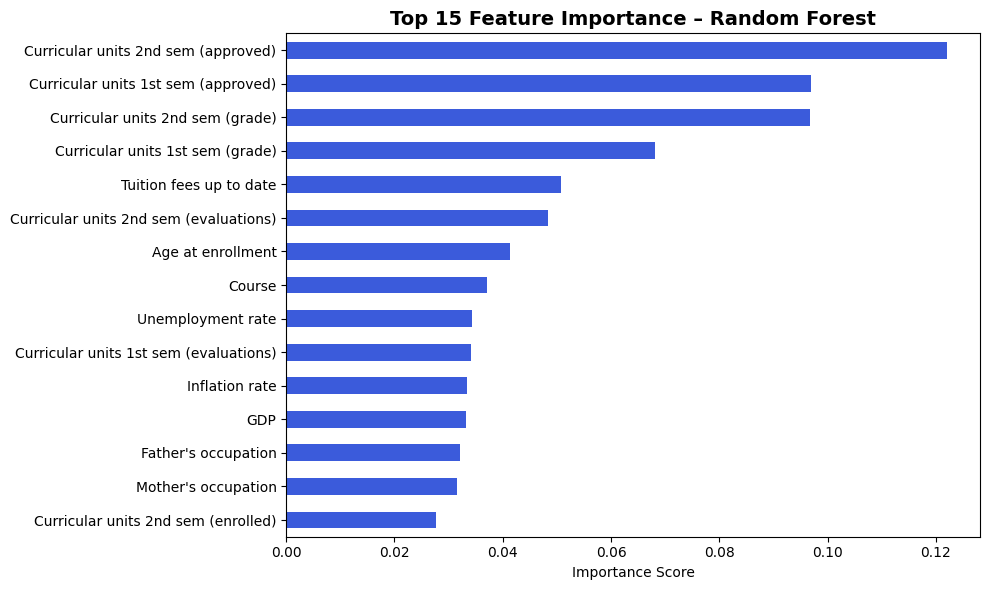


Top 15 Fitur Paling Berpengaruh:
   1. Curricular units 2nd sem (approved)           0.1221
   2. Curricular units 1st sem (approved)           0.0970
   3. Curricular units 2nd sem (grade)              0.0968
   4. Curricular units 1st sem (grade)              0.0681
   5. Tuition fees up to date                       0.0508
   6. Curricular units 2nd sem (evaluations)        0.0484
   7. Age at enrollment                             0.0413
   8. Course                                        0.0370
   9. Unemployment rate                             0.0344
  10. Curricular units 1st sem (evaluations)        0.0340
  11. Inflation rate                                0.0334
  12. GDP                                           0.0331
  13. Father's occupation                           0.0320
  14. Mother's occupation                           0.0316
  15. Curricular units 2nd sem (enrolled)           0.0277


In [6]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='#3B5BDB')
ax.set_title('Top 15 Feature Importance – Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 15 Fitur Paling Berpengaruh:")
for i, (feat, imp) in enumerate(feat_imp.items(), 1):
    print(f"  {i:2d}. {feat:<45} {imp:.4f}")

## 6. Simpan Model & Scaler

In [7]:
import os, pickle

OUTPUT_DIR = os.path.dirname(os.path.abspath('Week5_Modeling.ipynb'))

with open(os.path.join(OUTPUT_DIR, 'model_random_forest.pkl'), 'wb') as f:
    pickle.dump(best_rf, f)

with open(os.path.join(OUTPUT_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(OUTPUT_DIR, 'columns.pkl'), 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print(f"✅ Berhasil disimpan di: {OUTPUT_DIR}")
print("   - model_random_forest.pkl")
print("   - scaler.pkl")
print("   - columns.pkl")

✅ Berhasil disimpan di: e:\Don-tBeDO\notebooks
   - model_random_forest.pkl
   - scaler.pkl
   - columns.pkl
